# **Global Youtube Statistics - Grupo 8**
### Integrantes
* Adán Omar Contreras Cortés - 202273519-8
* Benjamín Alfredo Leiton Bravo - 202273614-3
* Sebastián Marcelo Canales Peña - 202273640-2
* Juan José García Bustamante - 202273595-3

# **Entrega 1**

## 1) Introducción 

YouTube es una de las plataformas de video en línea más grandes y populares del mundo. Se ha convertido en un pilar del entretenimiento digital y la educación, permitiendo a los usuarios subir, compartir y consumir videos sobre prácticamente cualquier tema, además, ha evolucionado como una herramienta esencial para creadores de contenido y empresas, ofreciendo oportunidades de monetización a través de la publicidad y suscripciones, mientras que su alcance global lo hace accesible a millones de usuarios en todos los rincones del mundo.
YouTube no solo impacta el entretenimiento, sino que también influye en el comportamiento social y cultural a nivel mundial.
Analizar datos de YouTube permite entender patrones de comportamiento de usuarios, tendencias de contenido, y el impacto que tienen factores como la geolocalización, las categorías de video, entre otros, en el éxito de los creadores de contenido.

<p align="center" width="50%">
    <img width="50%" src="https://wallpapers.com/images/featured-full/logo-de-youtube-hgf3z998485wnkh6.jpg">
</p>


## 2) Limpieza de Dataset
Es importante eliminar valores atípicos (outliers) y manejar los datos faltantes. Esto asegura que las estadísticas no estén sesgadas y que los gráficos representen la verdadera naturaleza de los datos, para esto, se realizará lo siguiente con el Dataset:
- Eliminar valores NaN: Para evitar que estos afecten las métricas y gráficos.
- Eliminar outliers: Datos que pueden distorsionar el análisis, como videos con reproducciones exageradamente altas o valores inusuales.
- Eliminar variables "innecesarias" y dejar variables que nos servirán para el análisis.

Utilizaremos *boxplots* con las variables para identificar valores *outliers*, y además, utilizaremos el método `.dropna()`, que nos permitirá eliminar los valores de tipo Nan.

In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from scipy.stats import gamma 
from scipy.optimize import minimize
from scipy.special import gamma as funcGamma

In [3]:
dataset = pd.read_csv("Global YouTube Statistics.csv")

clean_dataset = dataset[['rank','subscribers','video views','category','uploads','Country','video_views_rank']]
clean_dataset.dropna()
'''
Variables eliminadas:
- LATITUDE
- LONGITUDE
- CREATED YEAR
- CREATED MONTH
- CREATED DATE
- POPULATION
- SUBSCRIBERS FOR THE LAST 30 DAYS
- LOWEST MONTHLY EARNINGS
- HIGHEST MONTHLY EARNINGS
- ABBREVIATION
- YOUTUBER
- TITLE
- Gross tertiary education enrollment (%)
'''

'\nVariables eliminadas:\n- LATITUDE\n- LONGITUDE\n- CREATED YEAR\n- CREATED MONTH\n- CREATED DATE\n- POPULATION\n- SUBSCRIBERS FOR THE LAST 30 DAYS\n- LOWEST MONTHLY EARNINGS\n- HIGHEST MONTHLY EARNINGS\n- ABBREVIATION\n- YOUTUBER\n- TITLE\n- Gross tertiary education enrollment (%)\n'

In [4]:
for x in clean_dataset:
    print(f'Columna {x}: {dataset[x].nunique()} subniveles')

Columna rank: 995 subniveles
Columna subscribers: 289 subniveles
Columna video views: 988 subniveles
Columna category: 18 subniveles
Columna uploads: 777 subniveles
Columna Country: 50 subniveles
Columna video_views_rank: 953 subniveles


Como no existen variables con 1 solo subnivel, las que hay actualmente permanecen.

In [5]:
print(clean_dataset.shape)
clean_dataset.head()

(1006, 7)


,rank,subscribers,video views,category,uploads,Country,video_views_rank
0,1,245000000.0,2.280000e+11,Music,20082,india,1.0
1,2,170000000.0,0.000000e+00,Film & Animation,1,United States,4055159.0
2,3,166000000.0,2.836884e+10,Entertainment,741,United States,48.0
3,4,162000000.0,1.640000e+11,Education,966,United States,2.0
4,5,159000000.0,1.480000e+11,Shows,116536,India,3.0


Pequeña visualización de las primeras 5 filas del Dataset Limpio.

In [6]:
clean_dataset.describe()

,rank,subscribers,video views,uploads,video_views_rank
count,1006.000000,1.003000e+03,1.006000e+03,1006.000000,1.005000e+03
mean,497.472167,2.319501e+07,1.112411e+10,9168.335984,5.607670e+05
std,288.738758,1.783047e+07,1.424148e+10,34028.189437,1.368886e+06
min,1.000000,1.230000e+07,0.000000e+00,0.000000,1.000000e+00
25%,247.250000,1.450000e+07,4.281427e+09,194.000000,3.220000e+02
50%,498.500000,1.770000e+07,7.751292e+09,726.500000,9.190000e+02
75%,748.750000,2.475000e+07,1.357357e+10,2606.500000,3.645000e+03
max,995.000000,2.450000e+08,2.280000e+11,301308.000000,4.057944e+06


Variables de tipo numérico, el apartado std hace referencia a la desviación estándar.

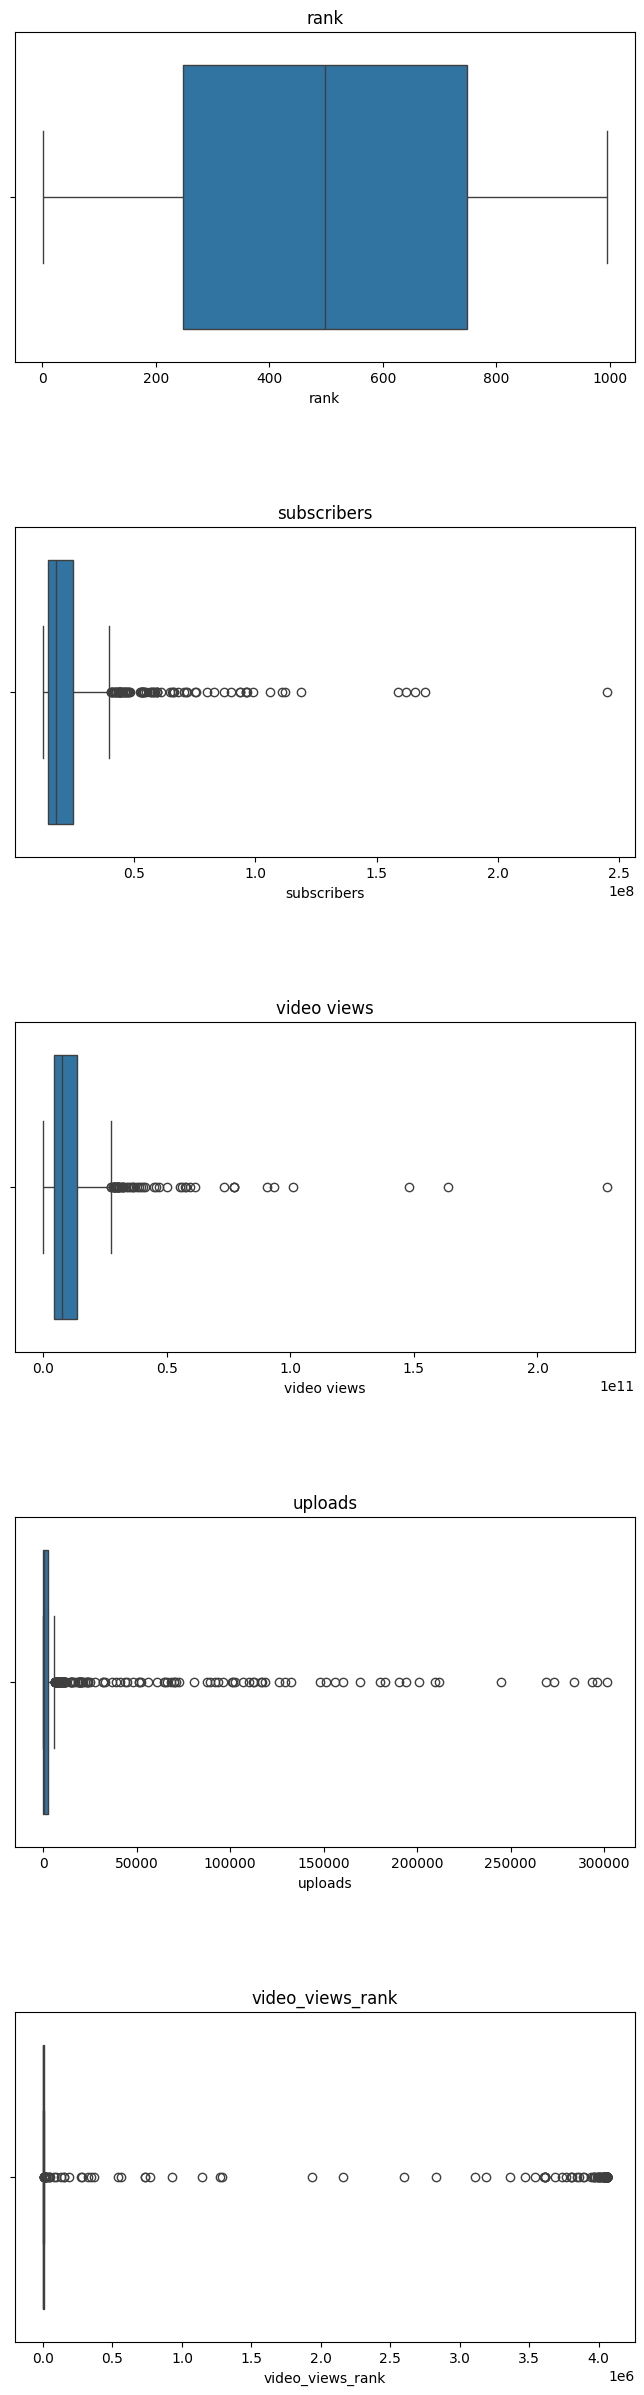

In [7]:
columnas_numericas = clean_dataset[['rank', 'subscribers','video views','uploads','video_views_rank']]

fig, ax = plt.subplots(nrows=5, ncols=1, figsize=(8,30))
fig.subplots_adjust(hspace=0.5)

for i, col in enumerate(columnas_numericas):
    sns.boxplot(x=col, data=clean_dataset, ax=ax[i])
    ax[i].set_title(col)

Se eliminarán los ultimos valores tanto para *video views* como para *subscribers*, ya que estos se considerarán **outliers** y afectan negativamente a algunos gráficos.

In [8]:
clean_dataset = clean_dataset[clean_dataset['video views'] <= 93247040539]
clean_dataset = clean_dataset[clean_dataset['subscribers'] <= 170000000]

## 3) Presentar información del dataset

Ya con el dataset limpio y ajustado, podemos empezar a graficar las distintas variables escogidas, para analizar los datos.

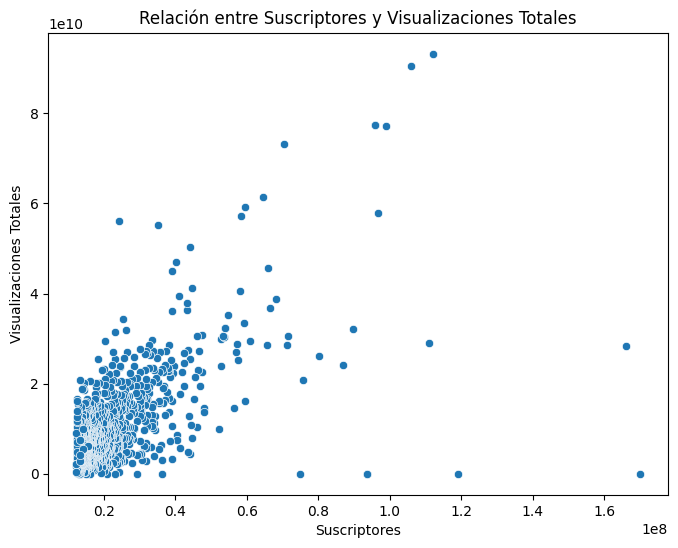

In [9]:

plt.figure(figsize=(8,6))
sns.scatterplot(x='subscribers', y='video views', data=clean_dataset)
plt.title('Relación entre Suscriptores y Visualizaciones Totales')
plt.xlabel('Suscriptores')
plt.ylabel('Visualizaciones Totales')
plt.show()


Este gráfico de dispersión nos muestra la relación de similitud entre las visualizaciones totales en base a los suscriptores

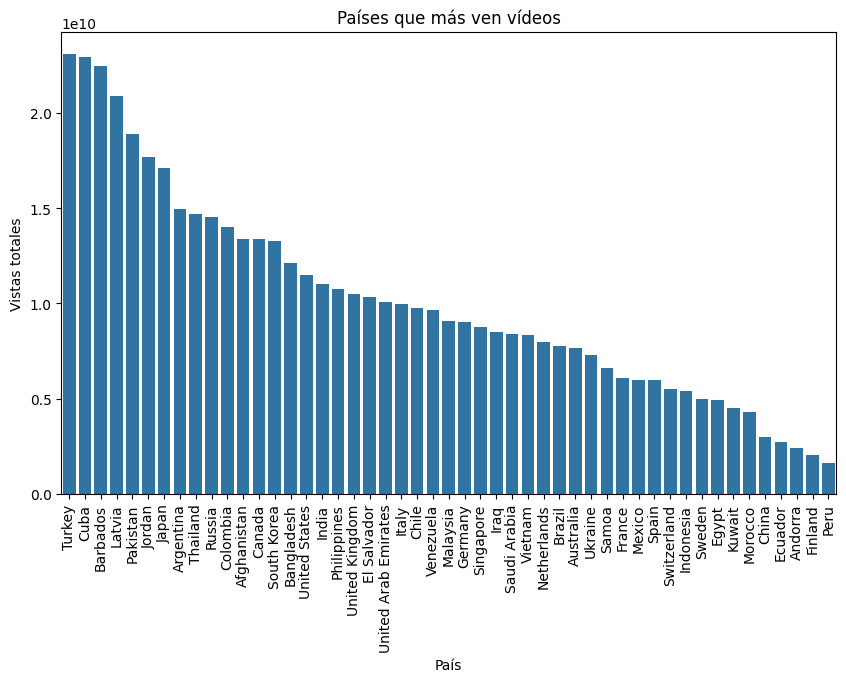

In [10]:
plt.figure(figsize=(10,6))
order = clean_dataset.groupby(['Country'])['video views'].mean().sort_values(ascending=False).index
sns.barplot(x='Country', y='video views', data=clean_dataset, order=order, errorbar=None)
plt.xticks(rotation=90)
plt.title('Países que más ven vídeos')
plt.xlabel('País')
plt.ylabel('Vistas totales')
plt.show()

Con este gráfico de barras, se puede observar claramente los países que más ven videos en la plataforma

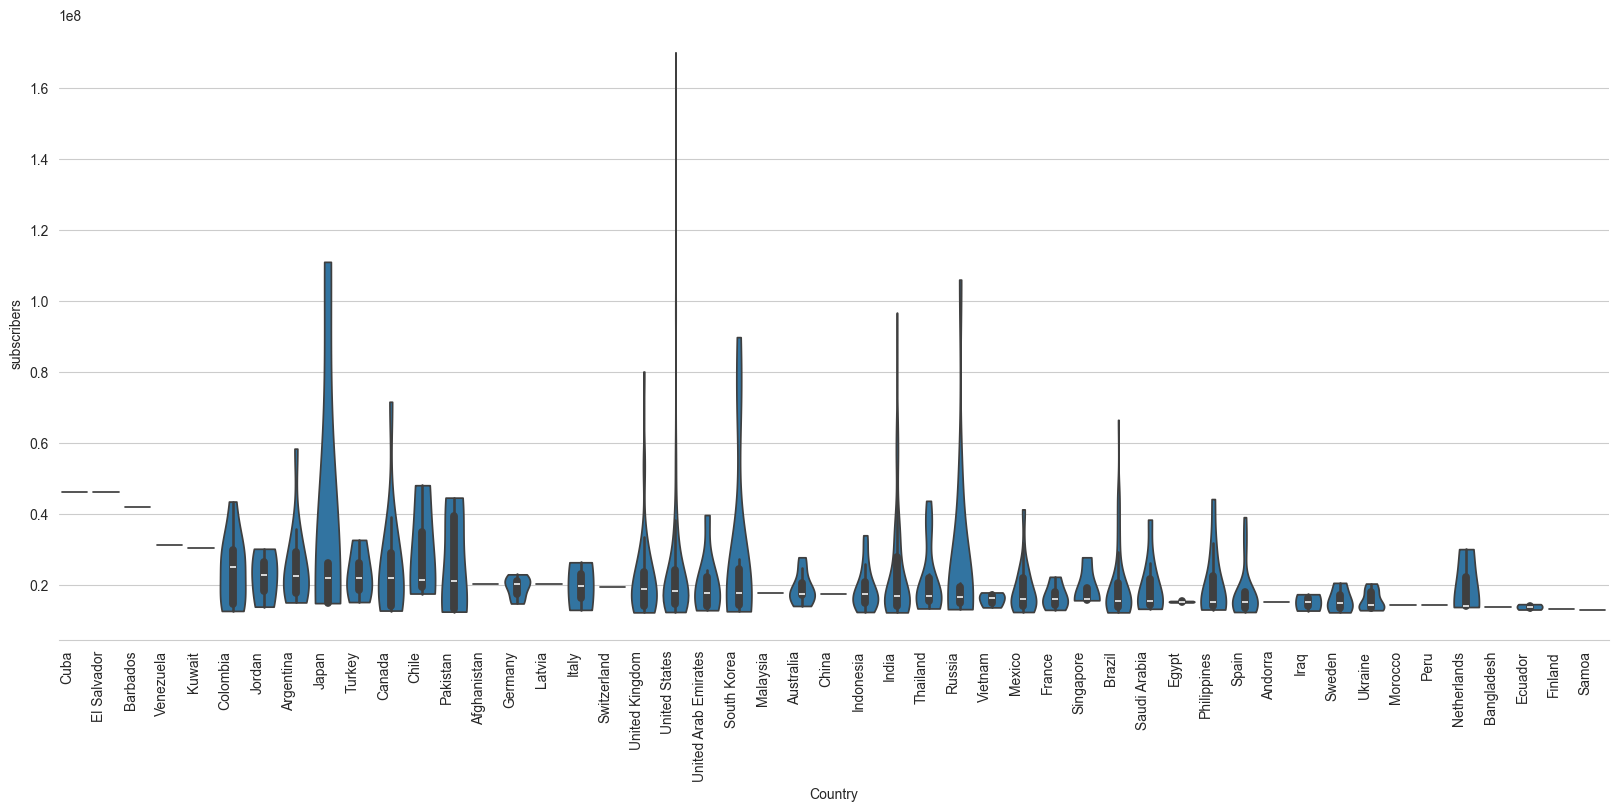

In [11]:
sns.set_style('whitegrid')
fig, ax = plt.subplots(figsize=(20, 8))
ordered = clean_dataset.groupby('Country')['subscribers'].median().sort_values(ascending=False).index

# Plot our violins.
sns.violinplot(x='Country', y='subscribers', data=clean_dataset, order= ordered, cut=0, density_norm='width')

# Rotate the x-axis labels and remove the plot border on the left.
_ = plt.xticks(rotation=90, ha='right')
sns.despine(left=True)

Este gráfico de violín nos muestra la distribución de suscriptores por país.

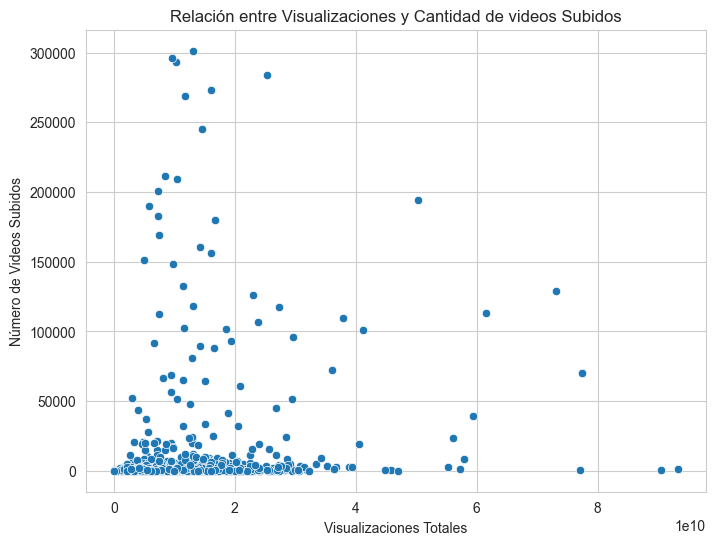

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='video views', y='uploads', data=clean_dataset)
plt.title('Relación entre Visualizaciones y Cantidad de videos Subidos')
plt.ylabel('Número de Videos Subidos')
plt.xlabel('Visualizaciones Totales')
plt.show()

Este gráfico de dispersión nos muestra la relación entre la cantidad de videos subidos vs las visualizaciones totales.

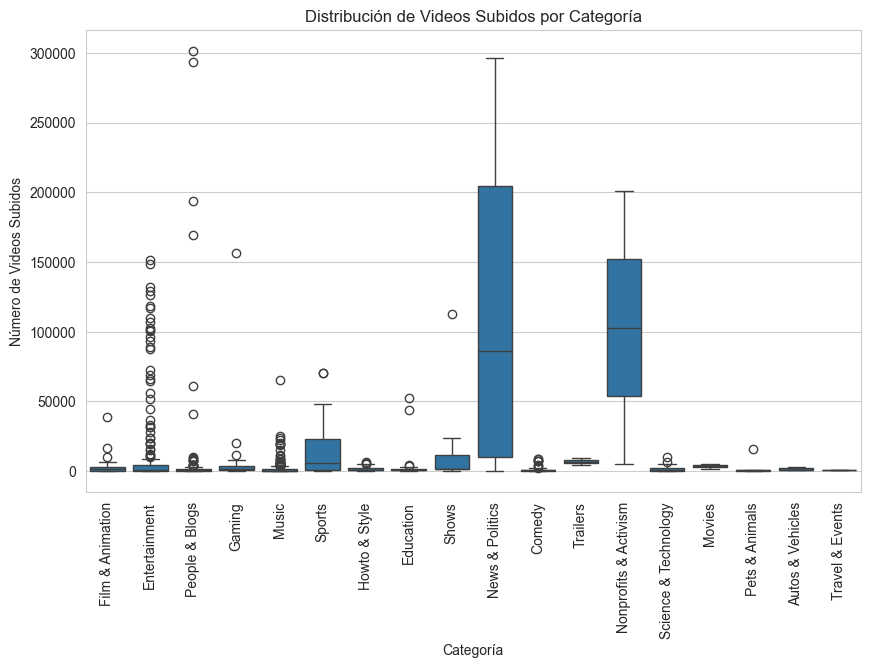

In [13]:
plt.figure(figsize=(10,6))
sns.boxplot(x='category', y='uploads', data=clean_dataset)
plt.xticks(rotation=90)
plt.title('Distribución de Videos Subidos por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Número de Videos Subidos')
plt.show()

Este gráfico de caja nos muestra la distribución de cantidad de videos subidos en base a su categoría.

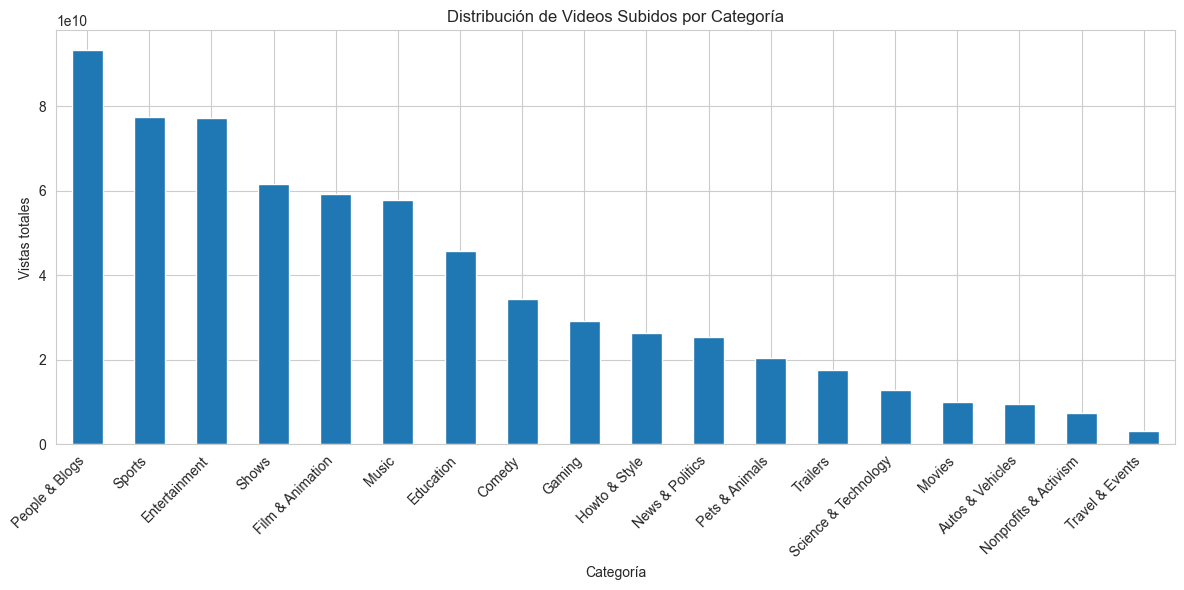

In [14]:
fig, ax = plt.subplots(figsize=(12, 6))
ordered_data = clean_dataset.groupby('category')['video views'].max().sort_values(ascending=False)
ordered_data.plot(kind='bar', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
plt.title('Distribución de Videos Subidos por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Vistas totales')
plt.tight_layout()
plt.show()

Este gráfico de barras nos muestra de forma simple la cantidad de vistas totales en base a las respectivas categorías.

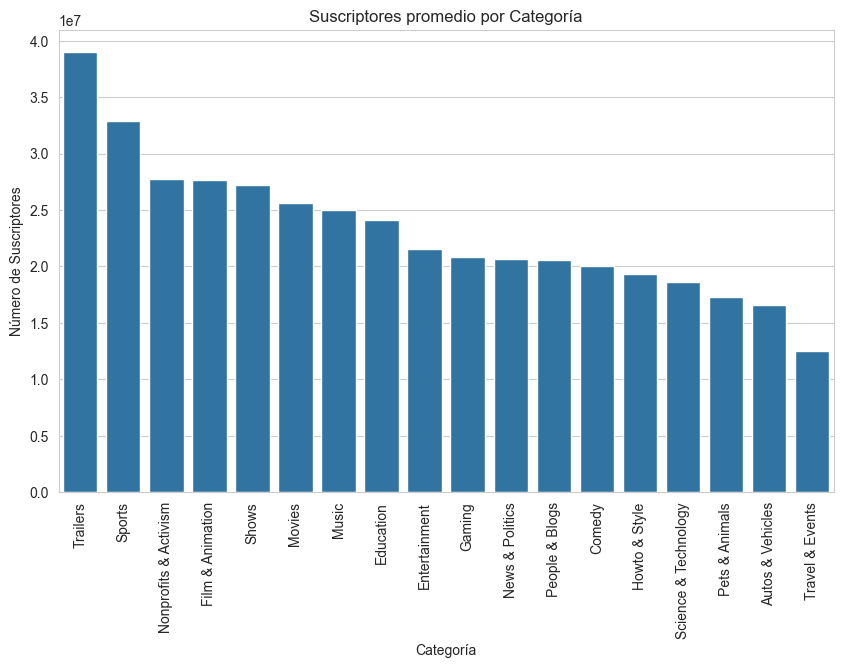

In [15]:
plt.figure(figsize=(10,6))
order = clean_dataset.groupby(['category'])['subscribers'].mean().sort_values(ascending=False).index
sns.barplot(x='category', y='subscribers', data=clean_dataset, order=order, errorbar=None)
plt.xticks(rotation=90)
plt.title('Suscriptores promedio por Categoría')
plt.xlabel('Categoría')
plt.ylabel('Número de Suscriptores')
plt.show()


Este gráfico de barras nos muestra de forma simple la cantidad promedio de suscriptores en cada categoría.

## 4) Variables a utilizar

Las variables que consideramos **principales** y que nos pueden arrojar mejores análisis son:
1. video views
2. category

Las visualizaciones totales indican de forma más directa el éxito y/o fama de un canal o un video en YouTube, además de representar el interés de la gente y el alcance del contenido.

La categoría de un canal o video es fundamental para entender de forma más específica las preferencias del público. Algunas categorías, como entretenimiento o música, pueden atraer audiencias más grandes, mientras que otras más especializadas pueden tener menos alcance.

También, pueden ayudar a complementar las siguientes **variables secundarias**:
1. uploads
2. subscribers

La cantidad de videos subidos refleja la actividad y consistencia de un canal. A mayor frecuencia de publicaciones, es probable que aumente el número de visualizaciones y suscriptores. Sin embargo, también es posible que la cantidad de videos no sea el único factor, sino la calidad o el tipo de contenido.

La cantidad de suscriptores es fundamental para medir el potencial a largo plazo del canal, o qué tan interesante es el contenido que suben. Además, nos permite ver cómo los suscriptores se relacionan con otros datos, como visualizaciones totales y categoría, para determinar si un canal con muchos suscriptores necesariamente genera más visualizaciones o ingresos.

In [16]:
vistas_totales = clean_dataset[["video views"]]
categoria = clean_dataset[["category"]]
videos_subidos = clean_dataset[["uploads"]]
suscriptores = clean_dataset[["subscribers"]]

## 5) Hipótesis y preguntas

Luego de analizar los graficos presentados del Dataset elegido, nos podemos cuestionar 
* ¿Qué relaciones existen entre los canales con más visitas y las categorías a las que corresponden?
* ¿Afecta la cantidad de videos subidos por estos o la cantidad de gente suscrita a ellos?

Las variables seleccionadas en el punto anterior nos permitirán determinar una respuesta para estas preguntas, y ver si realmente estas se relacionan entre sí, además de propiciarnos saber qué clase de contenidos prefiere la población y qué tan pendientes están de la gente que se dedica a subír videos sobre eso.

# **Entrega 2**

## Retroalimentaciones

Como equipo, se nos entregaron las siguientes retroalimentaciones con respecto a la entrega 1:
* Ordenar los gráficos de barra en orden descendente
* Corroborar el gráfico de violín utilizado
* Se eliminó una hipótesis que variaba demasiado de las otras dos.

Esto ha sido arreglado, y se podrá ver reflejado en sus respectivas secciones en la entrega 1, ahora, procederemos con lo solicitado para la entrega 2.

## 1) Variables a escoger 

Para este avance, vamos a enfocarnos en las siguientes Variables:

* Cantidad de videos subidos ("uploads") :  Esta variable indica la frecuencia de publicación, que, según la hipótesis, puede influir directamente en el alcance y éxito del canal.

* Cantidad de suscriptores ("subscribers") : Como medida del alcance y fidelidad de la audiencia, modelar esta variable permitirá comprobar si una mayor actividad de publicación se traduce efectivamente en más suscriptores, validando o ajustando la hipótesis original.

## 2) Estimación de parámetros mediante el método de los momentos y máxima verosimilitud

Para la cantidad de suscriptores (variable "subscribers") y numero de videos subidos (variable "uploads"), utilizaremos la Distribución Gamma:

Función de densidad:

$$ f(x;\alpha,\beta) = \frac{x^{\alpha - 1}e^{\frac{-x}{\beta}}}{\beta^{\alpha}\Gamma(\alpha)} $$

* Estimación por momentos:

    $ E[X] = \alpha \beta \ (media) $

    $ Var(X) = \alpha \beta^2 \ (varianza) $

    A partir de la media y la varianza observadas en los datos, podemos estimar $ \alpha $ y $ \beta $

* Estimación por máxima verosimilitud (MLE):

    La función de verosimilitud se maximiza con respecto a $ \alpha $ y $ \beta $, resolviendo las derivadas.

    $$ L(\alpha,\beta) = \prod_{i=1}^{n} \frac{x_{i}^{\alpha -1}e^{\frac{-x_i}{\beta}}}{\beta^{\alpha}\Gamma(\alpha)} $$

La vamos a utilizar para modelar variables continuas no negativas, como la cantidad de suscriptores. Además, se adapta bien a escenarios con alta variabilidad como es el caso de la cantidad de suscriptores.

Para la cantidad de videos subidos (variable "uploads") vamos a volver a utilizar funcion gama con esta variable, puesto que estas 2 variables se comportan de forma similar y para poder analizarlas y correlacionarlas vamos a aplicarle a ambas funcion gamma para tener más claridad sobre sus distribuciones.


## 3) Resultados Paso 2
Ahora que hemos definidos las distribuciones que usaremos para las variables, 

* Desarrollo Gamma:

Para calcular $ \beta $ y $ \alpha $, a partir del metodo de los momentos tenemos:
$$
E(X) =\alpha\beta = \overline{x}
$$
$$
E(X^2) = \alpha^2\beta^2 + \beta^2\alpha
$$
Despejando $ \alpha $ y $ \beta $:


$$ \beta=\frac{\frac{1}{n}\Sigma _i x^2_i-\bar X^2}{\bar X} $$

$$ \alpha=\frac{\bar X ^2}{\frac{1}{n}\Sigma _i x^2_i-\bar X^2} = \frac{\bar X}{\beta} $$


In [17]:
data = clean_dataset[["subscribers"]]
media = data.mean()
varianza = data.var()

print("Media:", media)
print("Varianza:", varianza)

# Para distribución gamma
beta = ((((1/data.count())) * np.square(data).sum() - (data.mean())**2)/data.mean())
alpha = data.mean()/beta

print("Alpha:",alpha)
print("Beta:",beta)

Media: subscribers    2.263824e+07
dtype: float64
Varianza: subscribers    2.282242e+14
dtype: float64
Alpha: subscribers    2.247804
dtype: float64
Beta: subscribers    1.007127e+07
dtype: float64


In [18]:
# Desarrollo Función Gamma
data = clean_dataset[["uploads"]]
media = data.mean()
varianza = data.var()

print("Media:", media)
print("Varianza:", varianza)

# Para distribución Gamma
beta = ((((1/data.count())) * np.square(data).sum() - (data.mean())**2)/data.mean())
alpha = data.mean()/beta

print("Alpha:",alpha)
print("Beta:",beta)


Media: uploads    9009.057057
dtype: float64
Varianza: uploads    1.150268e+09
dtype: float64
Alpha: uploads    0.070631
dtype: float64
Beta: uploads    127551.25531
dtype: float64


Obteniendo así:

**Función de densidad de 'suscribers':** $ f(x) = \frac{x^{1.25}e^{\frac{-x}{10071270}}}{10071270^{2.25}\Gamma(2.25)} $

**Función de densidad de 'uploads':** $ f(x) = \frac{x^{-0.93}e^{\frac{-x}{127551}}}{127551^{0.07}\Gamma(0.07)} $

In [19]:

print("Gamma(2.25) =", funcGamma(2.25))
print("Gamma(0.07) =", funcGamma(0.07))

Gamma(2.25) = 1.1330030963193463
Gamma(0.07) = 13.773600607733806


Obteniendo finalmente:

Función de densidad de 'suscribers': $ f(x) = \frac{x^{1.25}e^{\frac{-x}{10071270}}}{6.474*10^{15}} $

Función de densidad de 'uploads': $ f(x) = \frac{x^{-0.93}e^{\frac{-x}{127551}}}{31.357} $

## 4) Graficos de los resultados paso 3

### Código para la Visualización de la Variable uploads (Distribución Gamma) 
1. Calcular media y varianza de uploads para los parámetros $\alpha$ y $\beta$ usando ambos métodos: método de los momentos y máxima verosimilitud (MLE).
2. Graficar el histograma de la variable, agregar la estimación de densidad kernel (KDE) y superponer las distribuciones obtenidas.

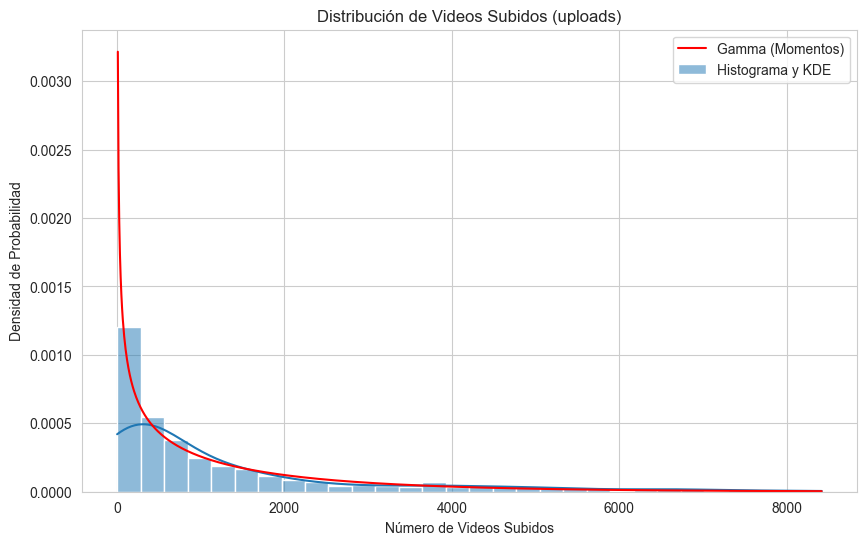

In [28]:
dataset_alterado = clean_dataset[clean_dataset['uploads'] <= 8500]
data = dataset_alterado[["uploads"]]
media = data.mean()
varianza = data.var()

# Para metodo momentos
beta_momento = ((((1/data.count())) * np.square(data).sum() - (data.mean())**2)/data.mean())
alpha_momento = data.mean()/beta_momento

# Para metodo máxima verosimilitud
#beta_maxver = 
#alpha_maxver = 

# Crear un rango de valores de x para la función de probabilidad
x = np.linspace(0, data.max(), 1000)

plt.figure(figsize=(10, 6))
sns.histplot(data, bins=30, kde=True, stat="density", color="orange", label="Histograma y KDE")
plt.plot(x, gamma.pdf(x, a=alpha_momento, scale=beta_momento), label="Gamma (Momentos)", color="red")
#plt.plot(x, gamma.pdf(x, a=alpha_maxver, scale=beta_maxver), label="Gamma (MLE)", color="green")
plt.title("Distribución de Videos Subidos (uploads)")
plt.xlabel("Número de Videos Subidos")
plt.ylabel("Densidad de Probabilidad")
plt.legend()
plt.show()


### Código para la Visualización de la Variable subscribers (Distribución Gamma) 
1. Calcular media y varianza de subscribers y los parámetros $\alpha$ y $\beta$ usando el método de los momentos y MLE.
2. Graficar el histograma, agregar KDE, y superponer las distribuciones obtenidas con ambos métodos.

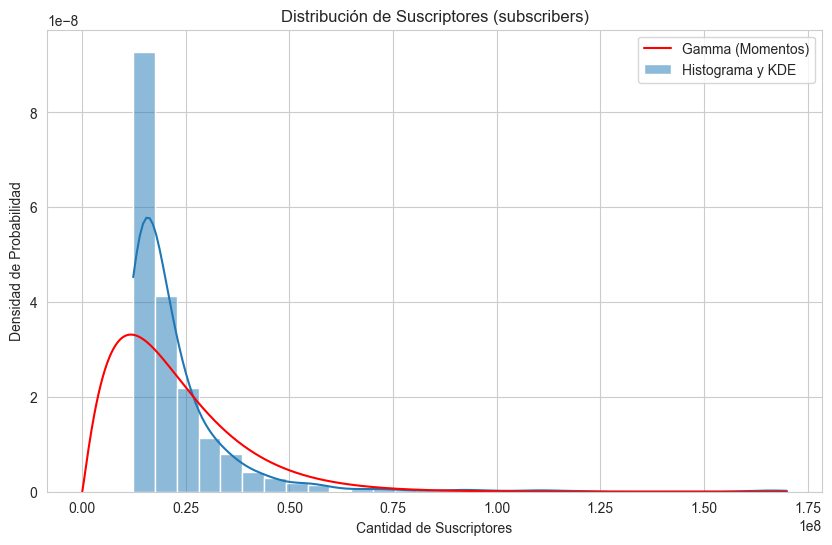

In [29]:

data = dataset_alterado[["subscribers"]]
media = data.mean()
varianza = data.var()

# Para metodo momentos
beta_momento = ((((1/data.count())) * np.square(data).sum() - (data.mean())**2)/data.mean())
alpha_momento = data.mean()/beta_momento

# Para metodo máxima verosimilitud
#beta_maxver = 
#alpha_maxver = 

# Crear un rango de valores de x para la función de probabilidad
x = np.linspace(0, data.max(), 1000)

plt.figure(figsize=(10, 6))
sns.histplot(data, bins=30, kde=True, stat="density", color="orange", label="Histograma y KDE")
plt.plot(x, gamma.pdf(x, a=alpha_momento, scale=beta_momento), label="Gamma (Momentos)", color="red")
#plt.plot(x, gamma.pdf(x, a=alpha_maxver, scale=beta_maxver), label="Gamma (MLE)", color="green")
plt.title("Distribución de Suscriptores (subscribers)")
plt.xlabel("Cantidad de Suscriptores")
plt.ylabel("Densidad de Probabilidad")
plt.legend()
plt.show()


## Simulación

## 5) Dividir el dataset y justificar el por qué 
Vamos a dividir el dataset en dos grupos: 

* Canales con cantidad de suscriptores mayor o igual 20.000.000
* Canales con cantidad de suscriptores menor a 20.000.000

Donde los canales con cantidad de suscriptores mayor o igual a corresponde a aproximandamente al 60% del dataset con el que se está trabajando.

Las columnas "Country" y "Category" fueron eliminadas, ya que en la última revisión se decidió descartar la hipótesis que justificaba su inclusión en el dataset. Dado que ahora estamos trabajando con las hipótesis actuales de este documento, mantener dichas columnas carece de sentido.


In [25]:
clean_dataset = dataset[['rank','subscribers','video views','uploads','video_views_rank']]
clean_dataset_upper = clean_dataset[clean_dataset['subscribers'] >= 20000000]
clean_dataset_lower = clean_dataset[clean_dataset['subscribers'] < 20000000]

## 6) Calcular la estimacion y mostrar los resultados (histograma, KDE y parametros estimados).

Escogeremos el método de momentos, utilizado en el inciso anterior, y lo aplicaremos al dataset en menor cantidad, que es "clean_dataset_lower"

Para calcular $ \beta $ y $ \alpha $, a partir del metodo de los momentos tenemos:
$$
E(X) =\alpha\beta = \overline{x}
$$
$$
E(X^2) = \alpha^2\beta^2 + \beta^2\alpha
$$
Despejando $ \alpha $ y $ \beta $:


$$ \beta=\frac{\frac{1}{n}\Sigma _i x^2_i-\bar X^2}{\bar X} $$

$$ \alpha=\frac{\bar X ^2}{\frac{1}{n}\Sigma _i x^2_i-\bar X^2} = \frac{\bar X}{\beta} $$



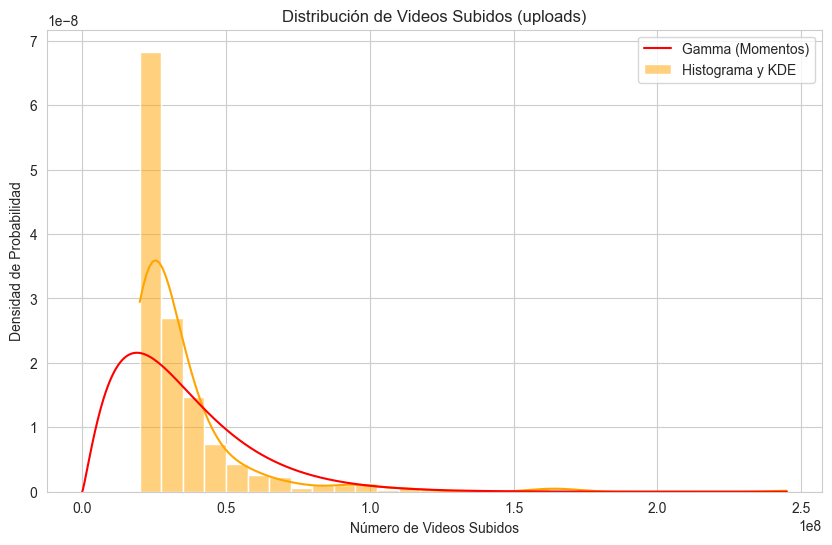

In [30]:
data = clean_dataset_upper['subscribers']
media = data.mean()
varianza = data.var()

# Para metodo momentos
beta_momento = ((((1/data.count())) * np.square(data).sum() - (data.mean())**2)/data.mean())
alpha_momento = data.mean()/beta_momento

# Crear un rango de valores de x para la función de probabilidad
x = np.linspace(0, data.max(), 1000)

plt.figure(figsize=(10, 6))
sns.histplot(data, bins=30, kde=True, stat="density", color="orange", label="Histograma y KDE")
plt.plot(x, gamma.pdf(x, a=alpha_momento, scale=beta_momento), label="Gamma (Momentos)", color="red")
plt.title("Distribución de Videos Subidos (uploads)")
plt.xlabel("Número de Videos Subidos")
plt.ylabel("Densidad de Probabilidad")
plt.legend()
plt.show()


## 7) Cantidad de datos necesaria para que ambas divisiones queden en la misma proporcion.

Para que ambas divisiones queden en la misma proporción (es decir, el mismo número de datos), debemos obtener también la cantidad de datos del dataset "clean_dataset_lower", mediante la distribución estimada.

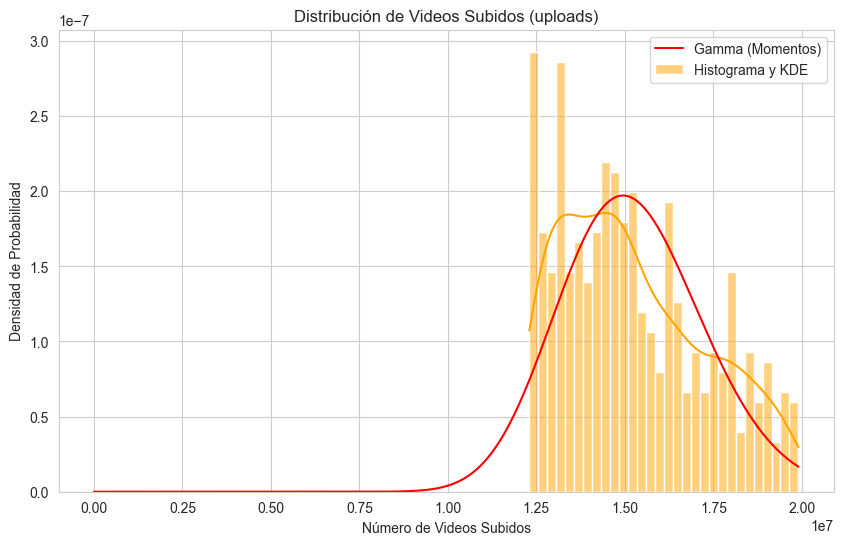

In [31]:
data = clean_dataset_lower['subscribers']
media = data.mean()
varianza = data.var()

# Para metodo momentos
beta_momento = ((((1/data.count())) * np.square(data).sum() - (data.mean())**2)/data.mean())
alpha_momento = data.mean()/beta_momento

# Crear un rango de valores de x para la función de probabilidad
x = np.linspace(0, data.max(), 1000)

plt.figure(figsize=(10, 6))
sns.histplot(data, bins=30, kde=True, stat="density", color="orange", label="Histograma y KDE")
plt.plot(x, gamma.pdf(x, a=alpha_momento, scale=beta_momento), label="Gamma (Momentos)", color="red")
plt.title("Distribución de Videos Subidos (uploads)")
plt.xlabel("Número de Videos Subidos")
plt.ylabel("Densidad de Probabilidad")
plt.legend()
plt.show()


Para este caso, en "clean_dataset_upper", existen 410 datos en total, mientras que en "clean_dataset_lower" existen 596, por lo que existe una diferencia de 186 datos contables, donde para el dataset general, aprox el 40.88% es mayor.

## 8) Preguntas

* ¿Que suposiciones haces al usar cada metodo de estimación?

Las supocisiones que hicimos al elegir el metodo de maxima verosimilitud es que, primero asumimos que el modelo utilizado, en este caso Gamma es adecuado para analizar este tipo de datos, la segunda supocision que hicimos es que las variables seleccionadas son independientes entre si, ademas de un espacio muestral lo suficientemente grande como para evitar el sesgo de las estimaciones.

* ¿Cuales son las limitaciones de los métodos de maxima verosimilitud y de los momentos en la practica?

las limitaciones para los metodos de maxima verosimilitud es que el metodo es computacionalmente complejo especialmente para distribuciones con muchos parametros lo que puede requerir mucha capacidad de calculo, y por ultimo para muestras muy pequeñas posee un sesgo muy grande con las distribuciones, que a medida que aumenta la muestra el sesgo disminuye.

* ¿Como podrías aplicar el modelo ajustado para hacer predicciones o inferencias sobre una nueva muestra de datos?

Con el modelo ajustado, se pueden predecir nuevos valores en una muestra futura y simular datos para observar su variabilidad esperada. Además, es posible calcular intervalos de confianza para los parámetros y realizar un contraste de hipótesis para evaluar su aplicacion a la hora de representar el comportamiento de los datos.

* ¿Que implicaciones tienen los parametros estimados en el contexto del problema real que modela el dataset?

Se presenta el como se distribuyen los datos, como se puede apreciar en los gráficos de subscriptores y videos subidos, hay una mayor cantidad de canales con pocos videos y un mayor cantidad de canales con pocos subscriptores

* ¿Que cambios puede observar en la distribucion del dataset luego de agregar los datos sinteticos?

Se puede apreciar que la curva no decae ya que, como dicho anteriormente nos concentramos ahora en los canales con pocos videos subidos y suscriptores, los cuales son donde mayor se concentra los datos. Mientras que el upper nos presenta la decaida de la curva al ver menor cantidad de canales. 

* ¿De que forma se puede validar los resultados que no sea de forma grafica?

Una log-verosimilitud elevada sugiere que el modelo ajustado representa bien los datos, facilitando la evaluación y comparación de distintos modelos.